In [17]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [18]:
#Libraries Insertion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from google.colab import files

#Model libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#Metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#DataFrame preparation
results_df = pd.DataFrame(columns=[
    'Classifier Name',
    'Training or test set',
    'Balanced or unbalanced train set',
    'Number of training samples',
    'Number of non-healthy companies in training sample',
    'True Positives (TP)',
    'True Negatives (TN)',
    'False Positives (FP)',
    'False Negatives (FN)',
    'ROC-AUC'
])

#Evaluation Functions

#Takes the predictions and returns TP,TN,FP,FN
def extract_cm_values(y_true, y_pred):
    """Calculates TP, TN, FP, FN from Confusion Matrix."""
    #labels=[1, 2]: 2 (Bankrupt) as Positive
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    return {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}

#Creating and displaying the heatmap of confusion matrix
def plot_confusion_matrix_custom(cm_values, model_name, set_type, fold):
    """Creating and displaying the Confusion Matrix."""
    cm_matrix = np.array([[cm_values['TN'], cm_values['FP']], [cm_values['FN'], cm_values['TP']]])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Healthy (1)', 'Pred: Bankrupt (2)'],
                yticklabels=['True: Healthy (1)', 'True: Bankrupt (2)'])
    plt.title(f'{model_name} - {set_type} - Fold {fold}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

#Evaluating model's answers while creating a dictionary
def calculate_required_metrics(y_true, y_pred, y_prob):
    """Calculates Accuracy, Precision, Recall, F1 score, ROC-AUC."""
    #pos_label=2: Focusing on Bankrupt prediction
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=2, zero_division=0),
        'Recall': recall_score(y_true, y_pred, pos_label=2, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, pos_label=2, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0
    }
    return metrics

#Central function - Calling the others - Adding new row in results_df
def log_results(df, model_name, set_type, balance_status, y_true, y_pred, y_prob, N_samples, N_non_healthy, fold):

    cm_values = extract_cm_values(y_true, y_pred)
    metrics = calculate_required_metrics(y_true, y_pred, y_prob)

    #Printing Confusion Matrix(9.a)
    plot_confusion_matrix_custom(cm_values, model_name, set_type, fold)

    #Printing results(9.c)
    print(f"[{set_type}] Acc: {metrics['Accuracy']:.2f}, F1: {metrics['F1 Score']:.2f}, AUC: {metrics['ROC-AUC']:.2f}")

    #Insertion to DataFrame(9.d)
    new_row = {
        'Classifier Name': model_name,
        'Training or test set': set_type,
        'Balanced or unbalanced train set': balance_status,
        'Number of training samples': N_samples,
        'Number of non-healthy companies in training sample': N_non_healthy,
        'True Positives (TP)': cm_values['TP'],
        'True Negatives (TN)': cm_values['TN'],
        'False Positives (FP)': cm_values['FP'],
        'False Negatives (FN)': cm_values['FN'],
        'ROC-AUC': metrics['ROC-AUC']
    }
    #Adding new row to df and returning it
    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

In [19]:
#Uploading(1)

print("\n--- Data loading ---")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_excel(filename)
    print("File loaded successfully!")
except FileNotFoundError:
    print("Error loading file.")

#Checking Missing Values(3)

if df.isnull().sum().sum() > 0:
    print("ALERT: Found missing values! Removing rows...")
    df_cleaned = df.dropna()
else:
    print("No missing values found.")
    df_cleaned = df


--- Data loading ---


Saving Dataset2Use_Assignment1.xlsx to Dataset2Use_Assignment1.xlsx
File loaded successfully!
No missing values found.



--- Data Visualisation(Figure 1 & 2) ---


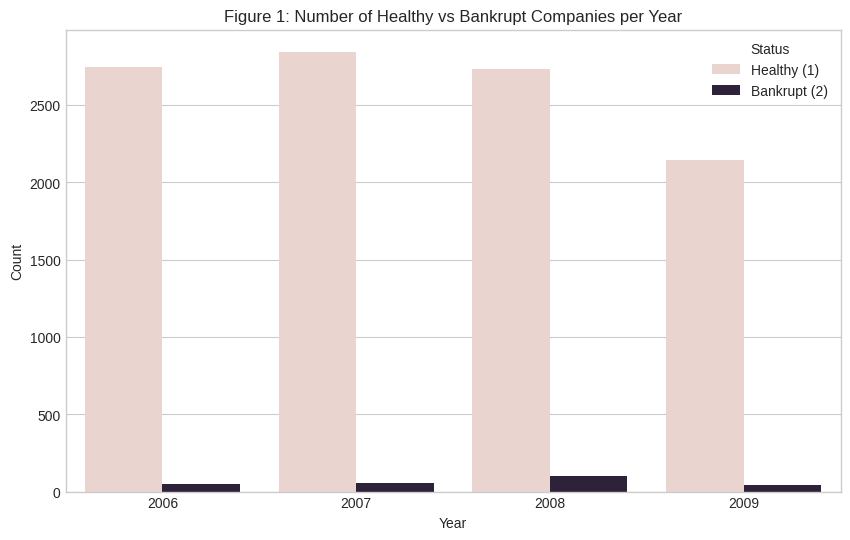

Performance Indicators identified: 8


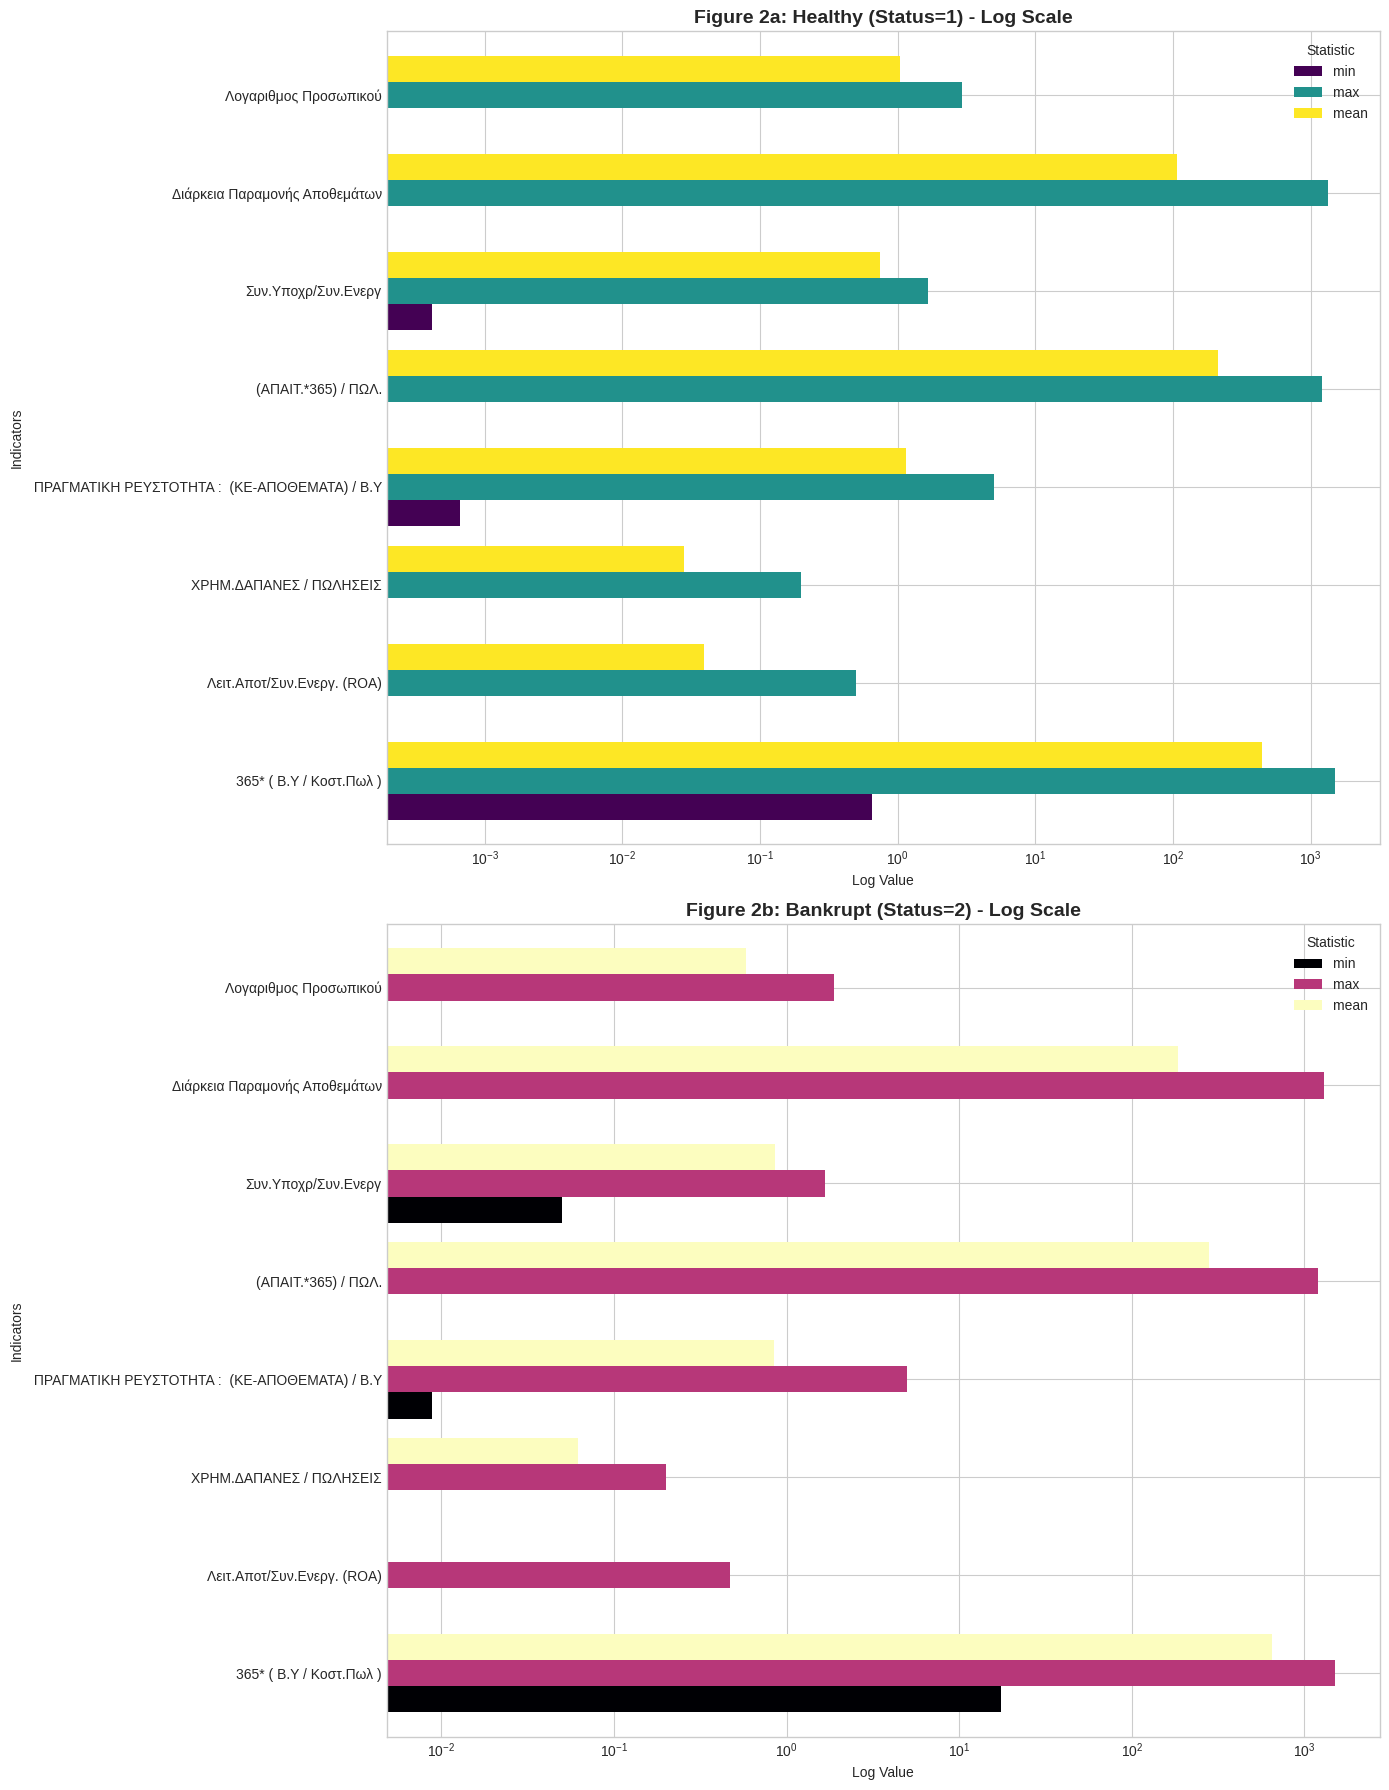

In [20]:
#Visualisation(2)

print("\n--- Data Visualisation(Figure 1 & 2) ---")

#Figure 1: Number of Healthy vs Bankrupt by each year
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='ΕΤΟΣ', hue='ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)')
plt.title('Figure 1: Number of Healthy vs Bankrupt Companies per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Healthy (1)', 'Bankrupt (2)'])
plt.show()

#Figure 2: Min, Max, Average for indicators
#Finding indicators columns (Performance Indicators)
feature_cols_all = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
#Excluded Columns
cols_to_exclude = ['ΕΤΟΣ', 'ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)', 'ΕΝΔΕΙΞΗ ΕΞΑΓΩΓΩΝ', 'ΕΝΔΕΙΞΗ ΕΙΣΑΓΩΓΩΝ', 'ΕΝΔΕΙΞΗ ΑΝΤΙΠΡΟΣΩΠΕΙΩΝ']
performance_cols = [c for c in feature_cols_all if c not in cols_to_exclude]

print(f"Performance Indicators identified: {len(performance_cols)}")

#Calculating stats (Min, Max, Average)
stats = df_cleaned.groupby('ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)')[performance_cols].agg(['min', 'max', 'mean'])

#Style
plt.style.use('seaborn-v0_8-whitegrid')

#Subplots creation
fig, axes = plt.subplots(2, 1, figsize=(14, 18))

#Healthy (1)
stats.loc[1].unstack(level=-1).plot(
    kind='barh',           #Horizontal
    ax=axes[0],
    logx=True,             #Showing every value
    width=0.8,
    colormap='viridis'
)
axes[0].set_title('Figure 2a: Healthy (Status=1) - Log Scale', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log Value')
axes[0].set_ylabel('Indicators')
axes[0].legend(title='Statistic')

#Bankrupt (2)
stats.loc[2].unstack(level=-1).plot(
    kind='barh',
    ax=axes[1],
    logx=True,
    width=0.8,
    colormap='magma'
)
axes[1].set_title('Figure 2b: Bankrupt (Status=2) - Log Scale', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log Value')
axes[1].set_ylabel('Indicators')
axes[1].legend(title='Statistic')

plt.tight_layout()
plt.show()

In [21]:
#Normalization(4)
print("\n--- Normalization ---")
scaler = MinMaxScaler()
df_scaled = df_cleaned.copy()
#Normalizing only the indicators
df_scaled[performance_cols] = scaler.fit_transform(df_cleaned[performance_cols])

# X: All the features (without Year and Target)
# y: The Target
target_col_name = 'ΕΝΔΕΙΞΗ ΑΣΥΝΕΠΕΙΑΣ (=2) (ν+1)'

X = df_scaled.drop(['ΕΤΟΣ', target_col_name], axis=1).values
y = df_scaled[target_col_name].values

print(f"Data ready. X shape: {X.shape}, y shape: {y.shape}")

#Model setup

models = {
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Random Forests": RandomForestClassifier(random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machines": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}




--- Normalization ---
Data ready. X shape: (10716, 11), y shape: (10716,)



--- Starting Cross-Validation ---

 --> FOLD 1 <--
Train Set Distribution: Healthy: 7851, Bankrupt: 186
Test Set Distribution:  Healthy: 2617, Bankrupt: 62
Applied Undersampling. New Healthy count: 558

 -> Model: Linear Discriminant Analysis


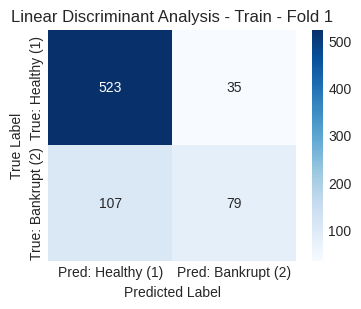

[Train] Acc: 0.81, F1: 0.53, AUC: 0.87


/tmp/ipython-input-243074843.py:109: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


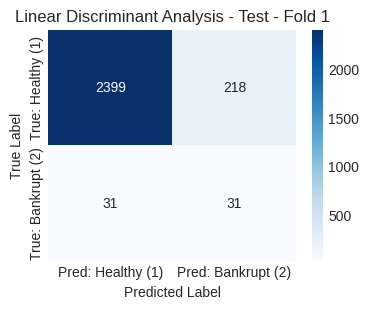

[Test] Acc: 0.91, F1: 0.20, AUC: 0.83

 -> Model: Logistic Regression


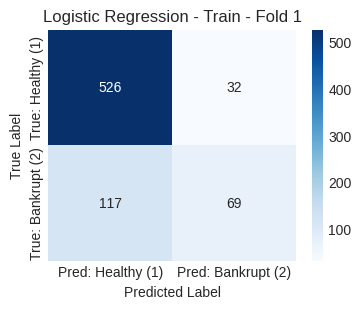

[Train] Acc: 0.80, F1: 0.48, AUC: 0.87


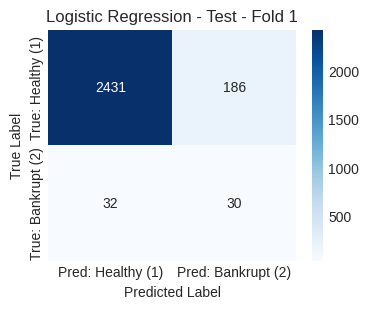

[Test] Acc: 0.92, F1: 0.22, AUC: 0.83

 -> Model: Decision Trees


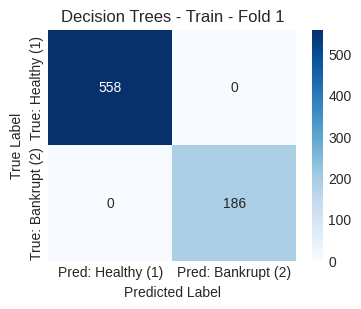

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


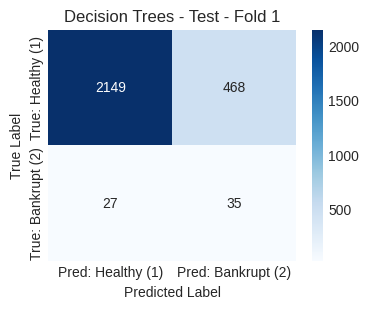

[Test] Acc: 0.82, F1: 0.12, AUC: 0.69

 -> Model: Random Forests


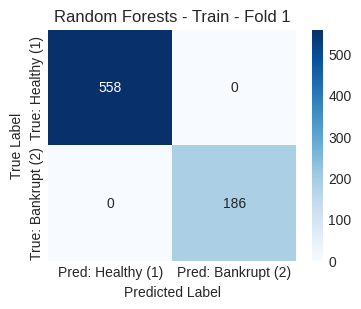

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


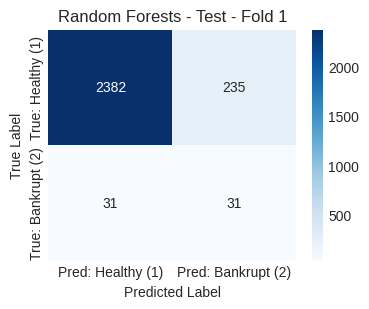

[Test] Acc: 0.90, F1: 0.19, AUC: 0.87

 -> Model: k-Nearest Neighbors


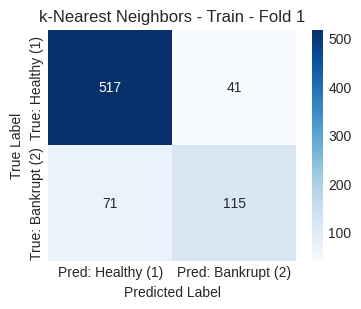

[Train] Acc: 0.85, F1: 0.67, AUC: 0.91


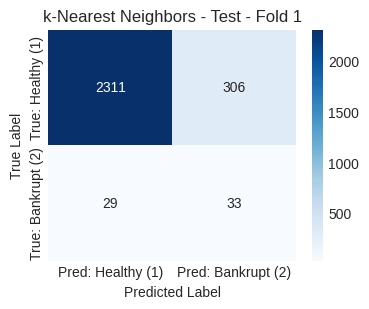

[Test] Acc: 0.87, F1: 0.16, AUC: 0.82

 -> Model: Naive Bayes


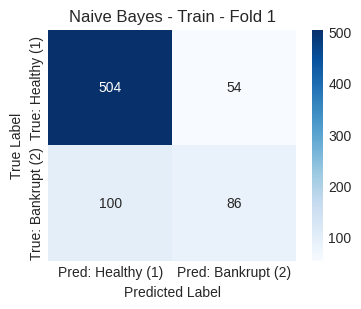

[Train] Acc: 0.79, F1: 0.53, AUC: 0.85


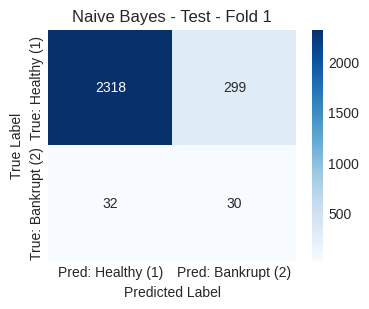

[Test] Acc: 0.88, F1: 0.15, AUC: 0.82

 -> Model: Support Vector Machines


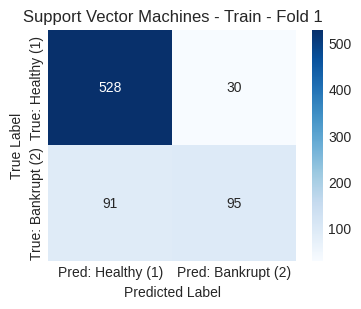

[Train] Acc: 0.84, F1: 0.61, AUC: 0.90


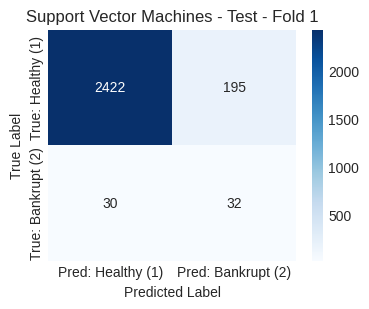

[Test] Acc: 0.92, F1: 0.22, AUC: 0.85

 -> Model: Gradient Boosting


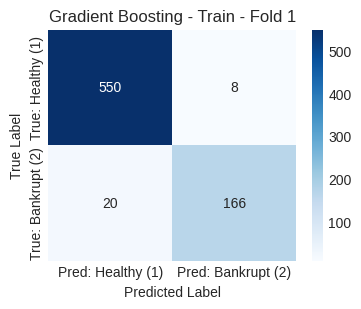

[Train] Acc: 0.96, F1: 0.92, AUC: 0.99


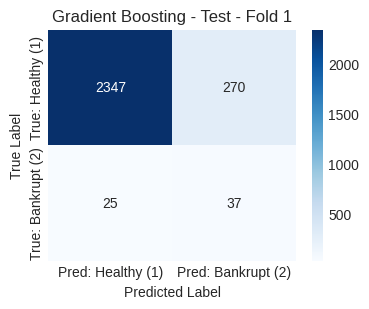

[Test] Acc: 0.89, F1: 0.20, AUC: 0.85

 --> FOLD 2 <--
Train Set Distribution: Healthy: 7851, Bankrupt: 186
Test Set Distribution:  Healthy: 2617, Bankrupt: 62
Applied Undersampling. New Healthy count: 558

 -> Model: Linear Discriminant Analysis


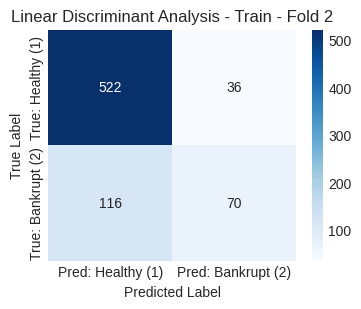

[Train] Acc: 0.80, F1: 0.48, AUC: 0.83


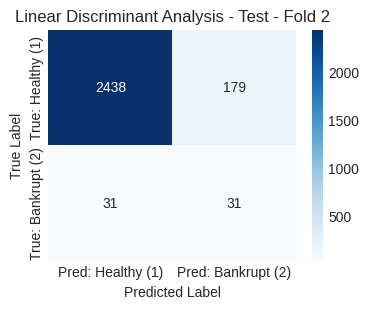

[Test] Acc: 0.92, F1: 0.23, AUC: 0.87

 -> Model: Logistic Regression


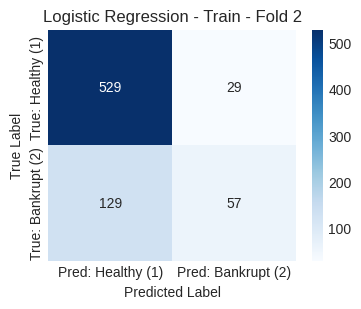

[Train] Acc: 0.79, F1: 0.42, AUC: 0.83


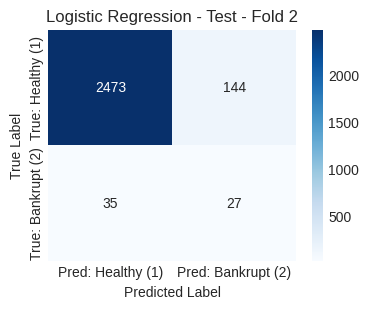

[Test] Acc: 0.93, F1: 0.23, AUC: 0.86

 -> Model: Decision Trees


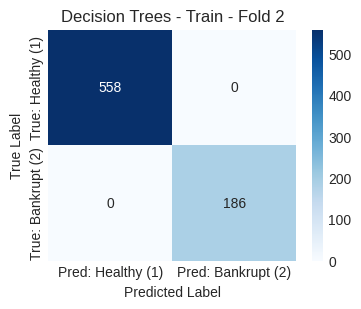

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


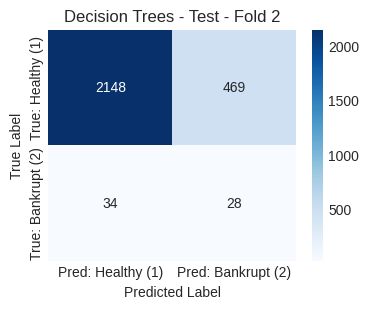

[Test] Acc: 0.81, F1: 0.10, AUC: 0.64

 -> Model: Random Forests


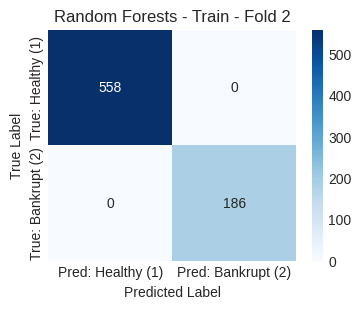

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


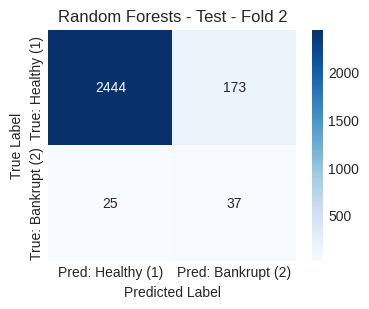

[Test] Acc: 0.93, F1: 0.27, AUC: 0.90

 -> Model: k-Nearest Neighbors


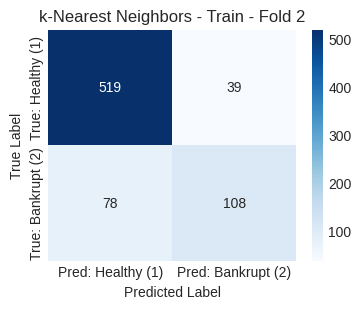

[Train] Acc: 0.84, F1: 0.65, AUC: 0.91


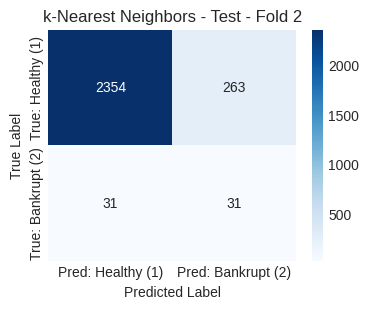

[Test] Acc: 0.89, F1: 0.17, AUC: 0.85

 -> Model: Naive Bayes


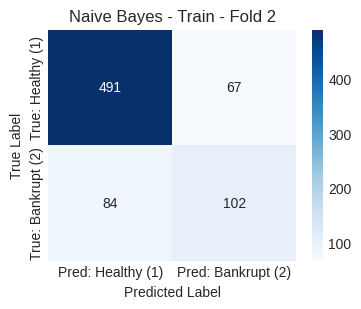

[Train] Acc: 0.80, F1: 0.57, AUC: 0.83


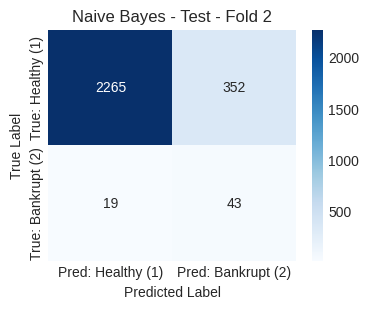

[Test] Acc: 0.86, F1: 0.19, AUC: 0.84

 -> Model: Support Vector Machines


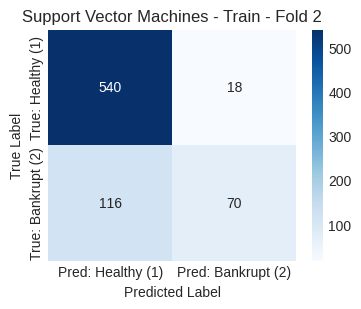

[Train] Acc: 0.82, F1: 0.51, AUC: 0.87


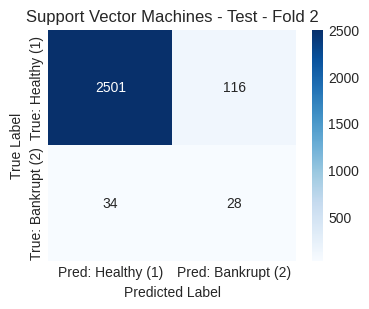

[Test] Acc: 0.94, F1: 0.27, AUC: 0.85

 -> Model: Gradient Boosting


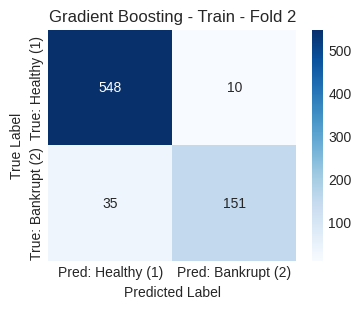

[Train] Acc: 0.94, F1: 0.87, AUC: 0.99


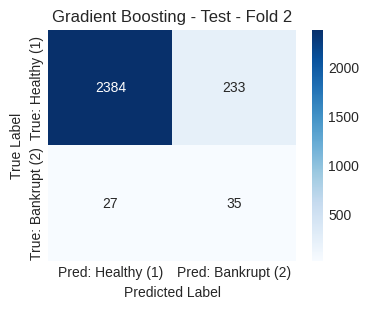

[Test] Acc: 0.90, F1: 0.21, AUC: 0.86

 --> FOLD 3 <--
Train Set Distribution: Healthy: 7851, Bankrupt: 186
Test Set Distribution:  Healthy: 2617, Bankrupt: 62
Applied Undersampling. New Healthy count: 558

 -> Model: Linear Discriminant Analysis


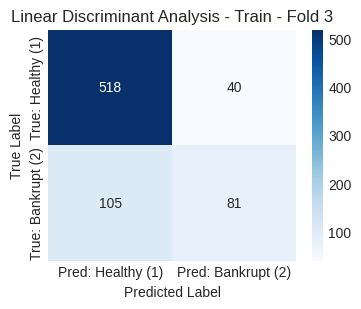

[Train] Acc: 0.81, F1: 0.53, AUC: 0.85


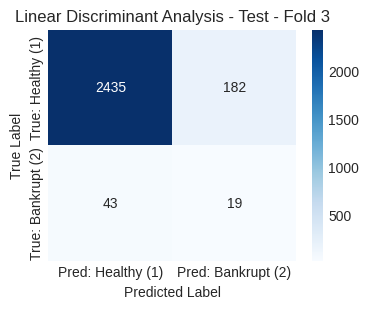

[Test] Acc: 0.92, F1: 0.14, AUC: 0.80

 -> Model: Logistic Regression


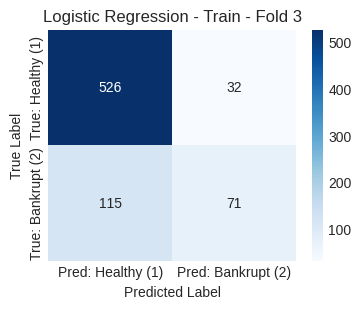

[Train] Acc: 0.80, F1: 0.49, AUC: 0.85


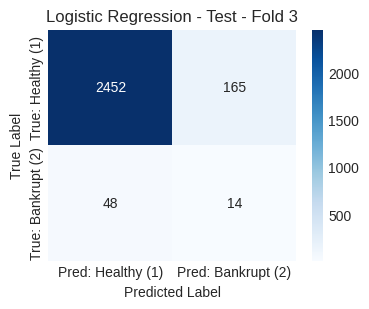

[Test] Acc: 0.92, F1: 0.12, AUC: 0.80

 -> Model: Decision Trees


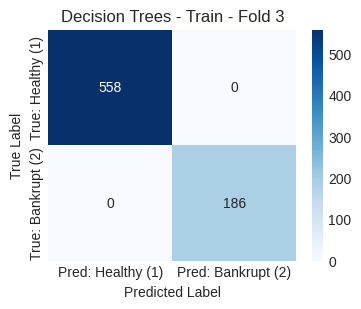

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


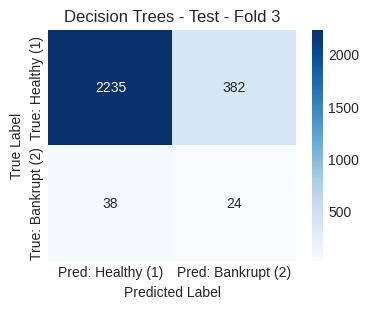

[Test] Acc: 0.84, F1: 0.10, AUC: 0.62

 -> Model: Random Forests


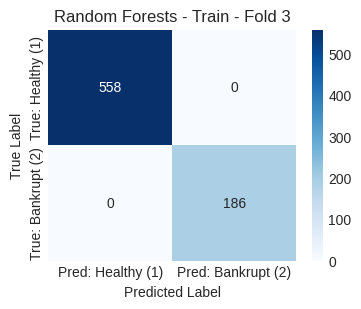

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


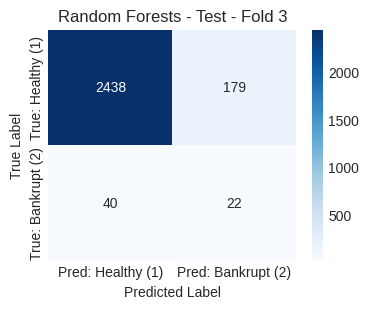

[Test] Acc: 0.92, F1: 0.17, AUC: 0.78

 -> Model: k-Nearest Neighbors


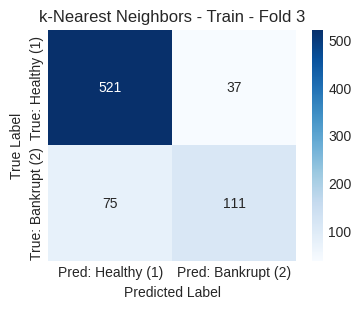

[Train] Acc: 0.85, F1: 0.66, AUC: 0.91


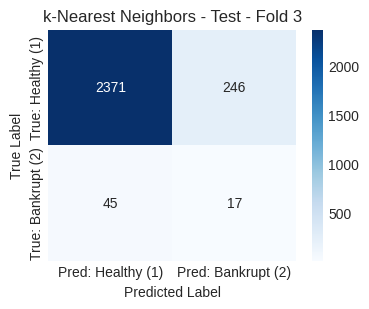

[Test] Acc: 0.89, F1: 0.10, AUC: 0.73

 -> Model: Naive Bayes


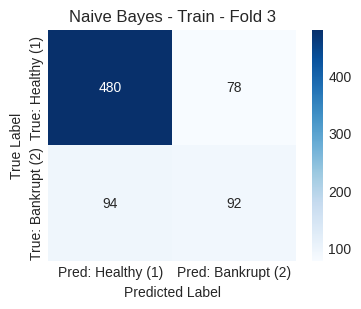

[Train] Acc: 0.77, F1: 0.52, AUC: 0.83


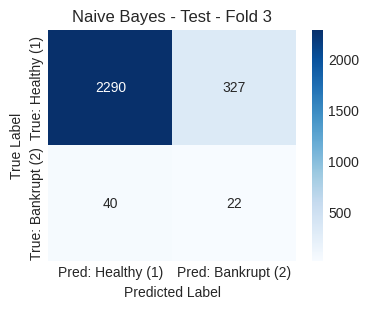

[Test] Acc: 0.86, F1: 0.11, AUC: 0.77

 -> Model: Support Vector Machines


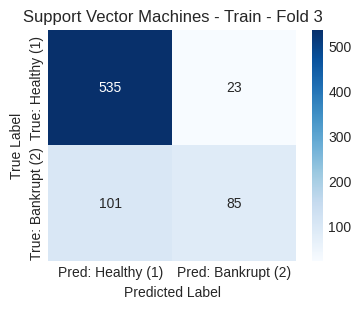

[Train] Acc: 0.83, F1: 0.58, AUC: 0.88


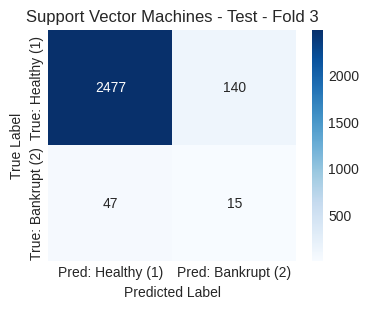

[Test] Acc: 0.93, F1: 0.14, AUC: 0.79

 -> Model: Gradient Boosting


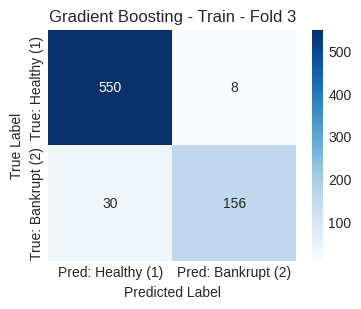

[Train] Acc: 0.95, F1: 0.89, AUC: 0.99


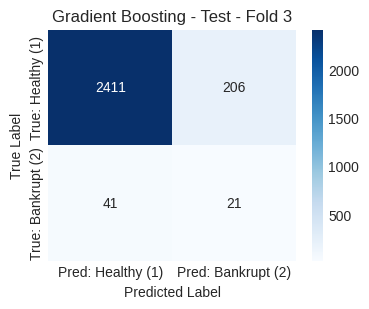

[Test] Acc: 0.91, F1: 0.15, AUC: 0.78

 --> FOLD 4 <--
Train Set Distribution: Healthy: 7851, Bankrupt: 186
Test Set Distribution:  Healthy: 2617, Bankrupt: 62
Applied Undersampling. New Healthy count: 558

 -> Model: Linear Discriminant Analysis


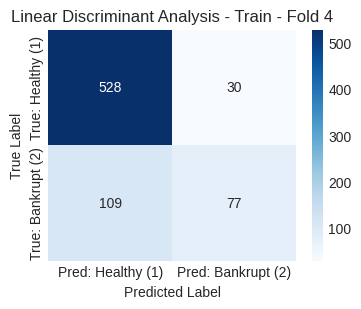

[Train] Acc: 0.81, F1: 0.53, AUC: 0.85


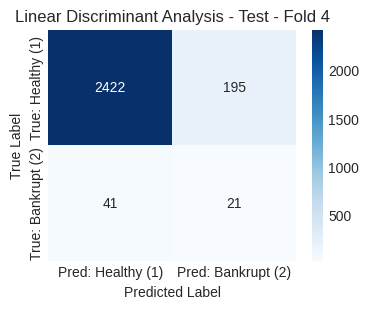

[Test] Acc: 0.91, F1: 0.15, AUC: 0.85

 -> Model: Logistic Regression


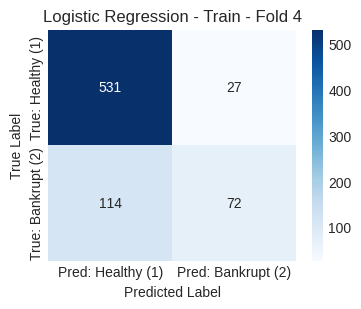

[Train] Acc: 0.81, F1: 0.51, AUC: 0.84


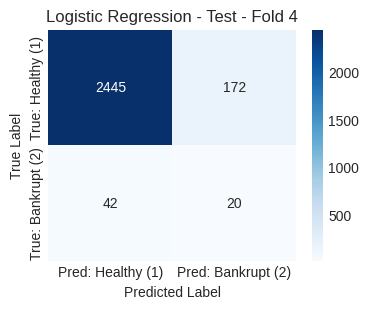

[Test] Acc: 0.92, F1: 0.16, AUC: 0.85

 -> Model: Decision Trees


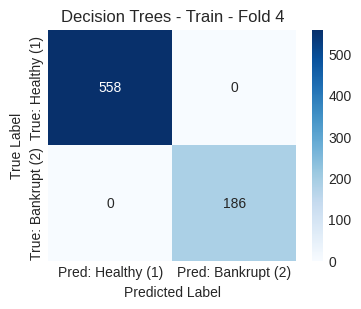

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


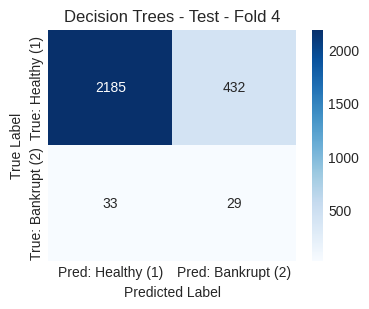

[Test] Acc: 0.83, F1: 0.11, AUC: 0.65

 -> Model: Random Forests


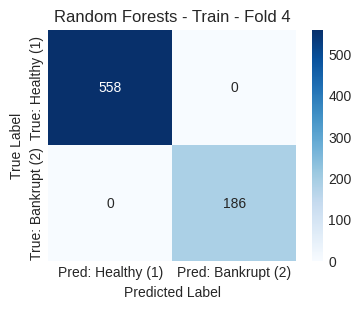

[Train] Acc: 1.00, F1: 1.00, AUC: 1.00


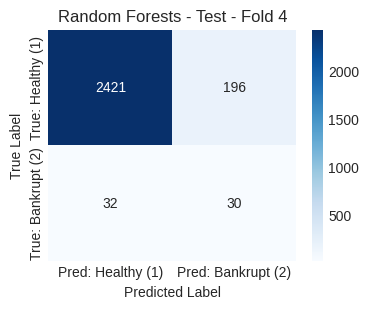

[Test] Acc: 0.91, F1: 0.21, AUC: 0.86

 -> Model: k-Nearest Neighbors


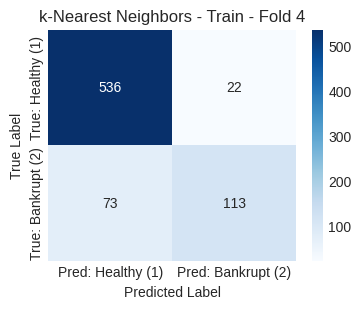

[Train] Acc: 0.87, F1: 0.70, AUC: 0.92


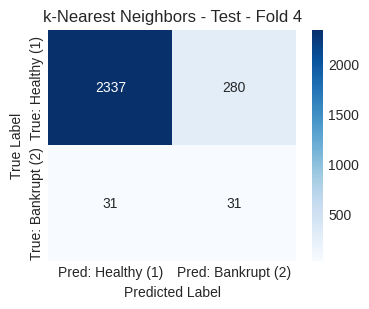

[Test] Acc: 0.88, F1: 0.17, AUC: 0.81

 -> Model: Naive Bayes


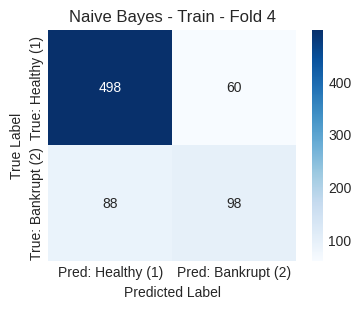

[Train] Acc: 0.80, F1: 0.57, AUC: 0.82


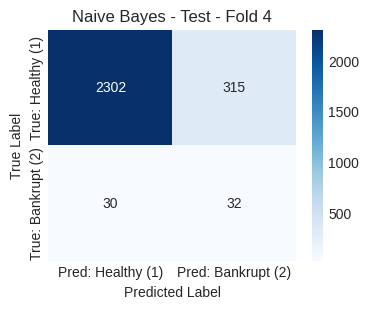

[Test] Acc: 0.87, F1: 0.16, AUC: 0.84

 -> Model: Support Vector Machines


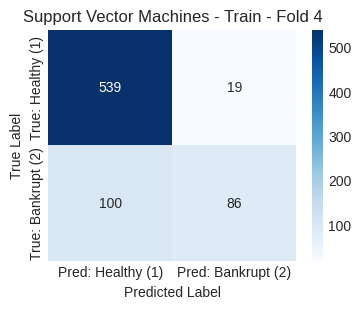

[Train] Acc: 0.84, F1: 0.59, AUC: 0.89


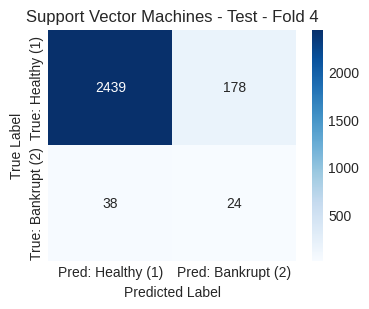

[Test] Acc: 0.92, F1: 0.18, AUC: 0.85

 -> Model: Gradient Boosting


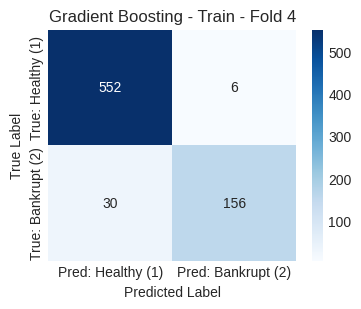

[Train] Acc: 0.95, F1: 0.90, AUC: 0.99


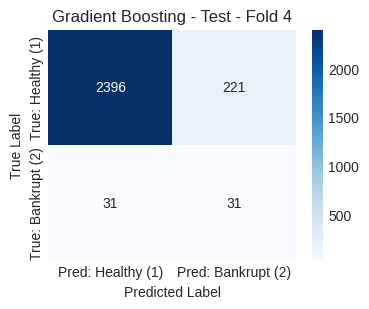

[Test] Acc: 0.91, F1: 0.20, AUC: 0.86


In [22]:
#Creating 4 folds(5)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

#Main Loop
print("\n--- Starting Cross-Validation ---")
for fold_number, (train_index, test_index) in enumerate(skf.split(X, y), 1):
    print(f"\n --> FOLD {fold_number} <--")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    #Number of healthy, bankrupt in train set (6.a)
    num_healthy_train = sum(y_train == 1)
    num_bankrupt_train = sum(y_train == 2)

    print(f"Train Set Distribution: Healthy: {num_healthy_train}, Bankrupt: {num_bankrupt_train}")

    #Number of healthy, bankrupt in test set (6.b)
    print(f"Test Set Distribution:  Healthy: {sum(y_test == 1)}, Bankrupt: {sum(y_test == 2)}")

    #Undersampling (7)
    if num_bankrupt_train == 0:
        X_train_balanced, y_train_balanced = X_train, y_train
        balance_status = 'N/A'
    elif num_healthy_train > (num_bankrupt_train * 3):
        # Apply undersampling
        healthy_indices = np.where(y_train == 1)[0]
        bankrupt_indices = np.where(y_train == 2)[0]

        healthy_indices_kept = resample(healthy_indices,
                                        n_samples=num_bankrupt_train * 3,
                                        random_state=42,
                                        replace=False)

        final_train_indices = np.concatenate([healthy_indices_kept, bankrupt_indices])
        X_train_balanced = X_train[final_train_indices]
        y_train_balanced = y_train[final_train_indices]
        balance_status = 'Balanced (3:1)'
        print(f"Applied Undersampling. New Healthy count: {len(healthy_indices_kept)}")
    else:
        X_train_balanced, y_train_balanced = X_train, y_train
        balance_status = 'Unbalanced'


    #Training and Evaluation (8, 9) (inner loop)
    for name, model in models.items():
        print(f"\n -> Model: {name}")

        #Training
        model.fit(X_train_balanced, y_train_balanced)

        #Predictions
        predictions_train = model.predict(X_train_balanced)
        predictions_test = model.predict(X_test)

        #Posibilities (AUC)
        try:
            probs_train = model.predict_proba(X_train_balanced)[:, 1]
            probs_test = model.predict_proba(X_test)[:, 1]
        except AttributeError:
             probs_train = model.decision_function(X_train_balanced)
             probs_test = model.decision_function(X_test)

        #Results

        #For Training Set
        results_df = log_results(
            df=results_df, model_name=name, set_type='Train',
            balance_status=balance_status,
            y_true=y_train_balanced, y_pred=predictions_train, y_prob=probs_train,
            N_samples=len(X_train_balanced), N_non_healthy=sum(y_train_balanced==2),
            fold=fold_number
        )

        #For Test Set
        results_df = log_results(
            df=results_df, model_name=name, set_type='Test',
            balance_status='N/A',
            y_true=y_test, y_pred=predictions_test, y_prob=probs_test,
            N_samples=len(X_test), N_non_healthy=sum(y_test==2),
            fold=fold_number
        )


In [23]:
#File save (10)
print("\n--- Saving Results to CSV ---")
csv_filename = 'balancedDataOutcomes.csv'
results_df.to_csv(csv_filename, index=False)
print(f"CSV saved locally as: {csv_filename}")

# AUTOMATION SCRIPT FOR EXCEL CALCULATIONS

df_excel = results_df.copy()

# metrics calculation
TP = df_excel['True Positives (TP)']
TN = df_excel['True Negatives (TN)']
FP = df_excel['False Positives (FP)']
FN = df_excel['False Negatives (FN)']

# Formulas from wikipedia
df_excel['Accuracy'] = (TP + TN) / (TP + TN + FP + FN)
df_excel['Precision'] = TP / (TP + FP)
df_excel['Recall'] = TP / (TP + FN) # Sensitivity (for bankruptcies)
df_excel['F1 Score'] = 2 * (df_excel['Precision'] * df_excel['Recall']) / (df_excel['Precision'] + df_excel['Recall'])

# Custom Metrics
df_excel['Specificity'] = TN / (TN + FP) # How well it detects Healthy companies (for the 70% criterion)
df_excel['Miss Rate'] = FN / (FN + TP)   # How many bankruptcies were missed

# Replace NaN with 0 (for safety)
df_excel = df_excel.fillna(0)

# extract to Excel and download
excel_filename = 'Final_Data_For_Excel.xlsx'
df_excel.to_excel(excel_filename, index=False)
print(f"Excel file created: {excel_filename}")

files.download(csv_filename)
files.download(excel_filename)


--- Saving Results to CSV ---
CSV saved locally as: balancedDataOutcomes.csv
Excel file created: Final_Data_For_Excel.xlsx


/tmp/ipython-input-4072935181.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_excel = df_excel.fillna(0)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>